In [1]:
!python --version

Python 3.11.14


In [2]:
import os, sys
import pandas as pd

from pathlib import Path
from sklearn.metrics import pairwise_distances


ROOT = Path().resolve().parent
SRC = os.path.join(ROOT, "src")

if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

print("ROOT:", ROOT)
print("SRC added:", SRC)

from libs.calc_degs_lib import CALC_DEGS
from libs.tcga_gdc_lib import *
from libs.Basic import *
from libs.stat_lib import *


ROOT: /home/flavio/uv/perturb_agent
SRC added: /home/flavio/uv/perturb_agent/src


### Defaults

In [3]:
ROOT = Path().resolve().parent
root0 = ROOT / "data"

gdc = GDC(root0=root0)

os.listdir(root0)[:10]


['cancer', 'reactome', 'vector_store', 'TCGA', 'gdc_programs.txt']

### Get all programs

In [4]:
force=False
verbose=True

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)


File read at '/home/flavio/uv/perturb_agent/data/gdc_programs.txt'


In [5]:
np.array(prog_list)

array(['TCGA', 'MATCH', 'TARGET', 'CGCI', 'CMI', 'APOLLO', 'BEATAML1.0',
       'CPTAC', 'MP2PRT', 'ALCHEMIST', 'CCDI', 'CCG', 'CDDP_EAGLE',
       'CTSP', 'EXCEPTIONAL_RESPONDERS', 'FM', 'HCMI', 'MMRF', 'NCICCR',
       'OHSU', 'ORGANOID', 'RC', 'REBC', 'TRIO', 'VAREPOP', 'WCDT'],
      dtype='<U22')

### Primary sites given a program

In [6]:
gdc.url_gdc_project

'https://api.gdc.cancer.gov/projects'

In [7]:
prog_id = 'TCGA'

gdc.set_program(prog_id)

In [8]:
df_psi = gdc.get_primary_sites(prog_id=prog_id, force=force, verbose=verbose)

primary_sites = np.unique(df_psi.primary_site.to_list())
primary_sites[:6]

Table opened ((33, 5)) at '/home/flavio/uv/perturb_agent/data/TCGA/primary_site_program_TCGA.tsv'


array(['Adrenal gland',
       'Adrenal gland, Retroperitoneum and peritoneum, Other endocrine glands and related structures, Other and ill-defined sites, Connective, subcutaneous and other soft tissues, Spinal cord, cranial nerves, and other parts of central nervous system, Heart, mediastinum, and pleura',
       'Bladder', 'Brain', 'Breast', 'Bronchus and lung'], dtype='<U471')

In [9]:
verbose=True

i = 0
primary_site = df_psi.iloc[i].primary_site
print(primary_site)

df_cases, df_all_samples, df_all_mut, barcode_list = gdc.get_filtered_tables(primary_site=primary_site, verbose=verbose)
print(len(df_all_mut))

Adrenal gland
Table opened ((92, 23)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-ACC/cases_for_TCGA-ACC.tsv'
Table opened ((4481, 14)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-ACC/samples_for_TCGA-ACC_Adrenal_gland_subtype_adrenal_cortical_carcinoma_tumor_adrenal_cortical_carcinoma_subtype_tissue_adrenal_cortical_carcinoma.tsv'
Table opened ((5389, 26)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-ACC/mutations_anal_for_study_TCGA-ACC_Adrenal_gland_subtype_adrenal_cortical_carcinoma_tumor_adrenal_cortical_carcinoma_subtype_tissue_adrenal_cortical_carcinoma.tsv'
Table opened ((4481, 14)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-ACC/samples_for_TCGA-ACC_Adrenal_gland_subtype_adrenal_cortical_carcinoma_tumor_adrenal_cortical_carcinoma_subtype_tissue_adrenal_cortical_carcinoma.tsv'
Table opened ((5389, 26)) at '/home/flavio/uv/perturb_agent/data/TCGA/TCGA-ACC/mutations_anal_for_study_TCGA-ACC_Adrenal_gland_subtype_adrenal_cortical_carcinoma_tumor_adrenal_cortical_

In [10]:
min_barcodes=3
min_genes=3

dfpiv = gdc.build_pivot_table(df_all_mut, min_barcodes=min_barcodes, min_genes=min_genes)
print(len(dfpiv))
dfpiv.head(2)

50


symbol,ADGRV1,AGBL1,AHNAK2,AKAP12,ALOX5,AMER3,ANKRD30B,ANO2,APBA2,ARHGEF28,...,TRPV4,TTC21A,TTN,UNC13C,VCAN,XDH,XIRP2,ZNF648,ZNF804B,ZNRF3
barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5J2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-OR-A5J4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Complete Cluster Analysis

In [11]:
verbose=False

i = 5
primary_site = df_psi.iloc[i].primary_site

k=5

# 
df, dfpur, dfclu, dfw, dfh, dfstat, dfpiv, df_all_mut = gdc.cluster_analysis(cluster_type="UMAP", primary_site=primary_site, k=k, Kmin=2, Kmax=10, 
						 min_barcodes=3, min_genes=5, pur_threshold=0.05, min_represent_perc=0.10, verbose=verbose)

Chose UMAP with k=5


In [12]:
df

,label,purity_norm,subtype,overlap,pval,fdr
0,4,0.228000,Luminal_A,5,3.050468e-12,2.135328e-11
1,4,0.228000,Lobular,4,1.170400e-09,4.096399e-09
2,3,0.110404,Luminal_A,2,4.912013e-04,5.730682e-04
3,3,0.110404,Lobular,2,3.518390e-04,4.925747e-04
4,2,0.064000,Luminal_A,4,4.834774e-07,8.460854e-07
5,2,0.064000,Luminal_B,2,1.885998e-03,1.885998e-03
6,2,0.064000,Lobular,4,2.088366e-07,4.872854e-07


In [13]:
dfpur

,label,n_barcodes,purity,n_pairs,purity_norm
4,4,17,0.228,136.0,0.228000
3,3,15,0.143,105.0,0.110404
2,2,17,0.064,136.0,0.064000
0,0,11,0.084,55.0,0.033971
1,1,2,1.000,1.0,0.007353


In [14]:
dfclu

cluster,0,1,2,3,4
symbol,,,,,
ABCA13,0.000000,0.0,0.000000,0.200000,0.000000
ARID1A,0.000000,0.0,0.235294,0.000000,0.000000
ATP10B,0.090909,0.0,0.058824,0.066667,0.000000
CDH1,0.181818,0.0,0.235294,0.000000,0.823529
CDH20,0.272727,0.0,0.000000,0.000000,0.000000
CHD4,0.272727,0.0,0.058824,0.000000,0.000000
CSMD2,0.090909,0.0,0.117647,0.133333,0.000000
DNAH1,0.000000,0.0,0.117647,0.066667,0.000000
EGR2,0.090909,0.0,0.176471,0.000000,0.000000


Label 2 | purity_norm=0.064 TTN, PIK3CA, ARID1A, MARF1, CDH1, MUC16, KMT2C, NF1, NCOR1, KMT2E, TBX3, GATA3, EGR2, NIPBL, TEX15, SPTA1, USP9X, MUC4, PHF3, MYH9, MAP2K4, HMCN1, DNAH1, CSMD2, WSCD2
Label 3 | purity_norm=0.110 PIK3CA, ABCA13, FOXA1, TSHZ3, CSMD2, FAT2, MUC16, MYH9, NHS, PHF3, WSCD2
Label 4 | purity_norm=0.228 CDH1, GATA3, LRP1B, RUNX1, FLG, MAP3K1, TBX3, TTN


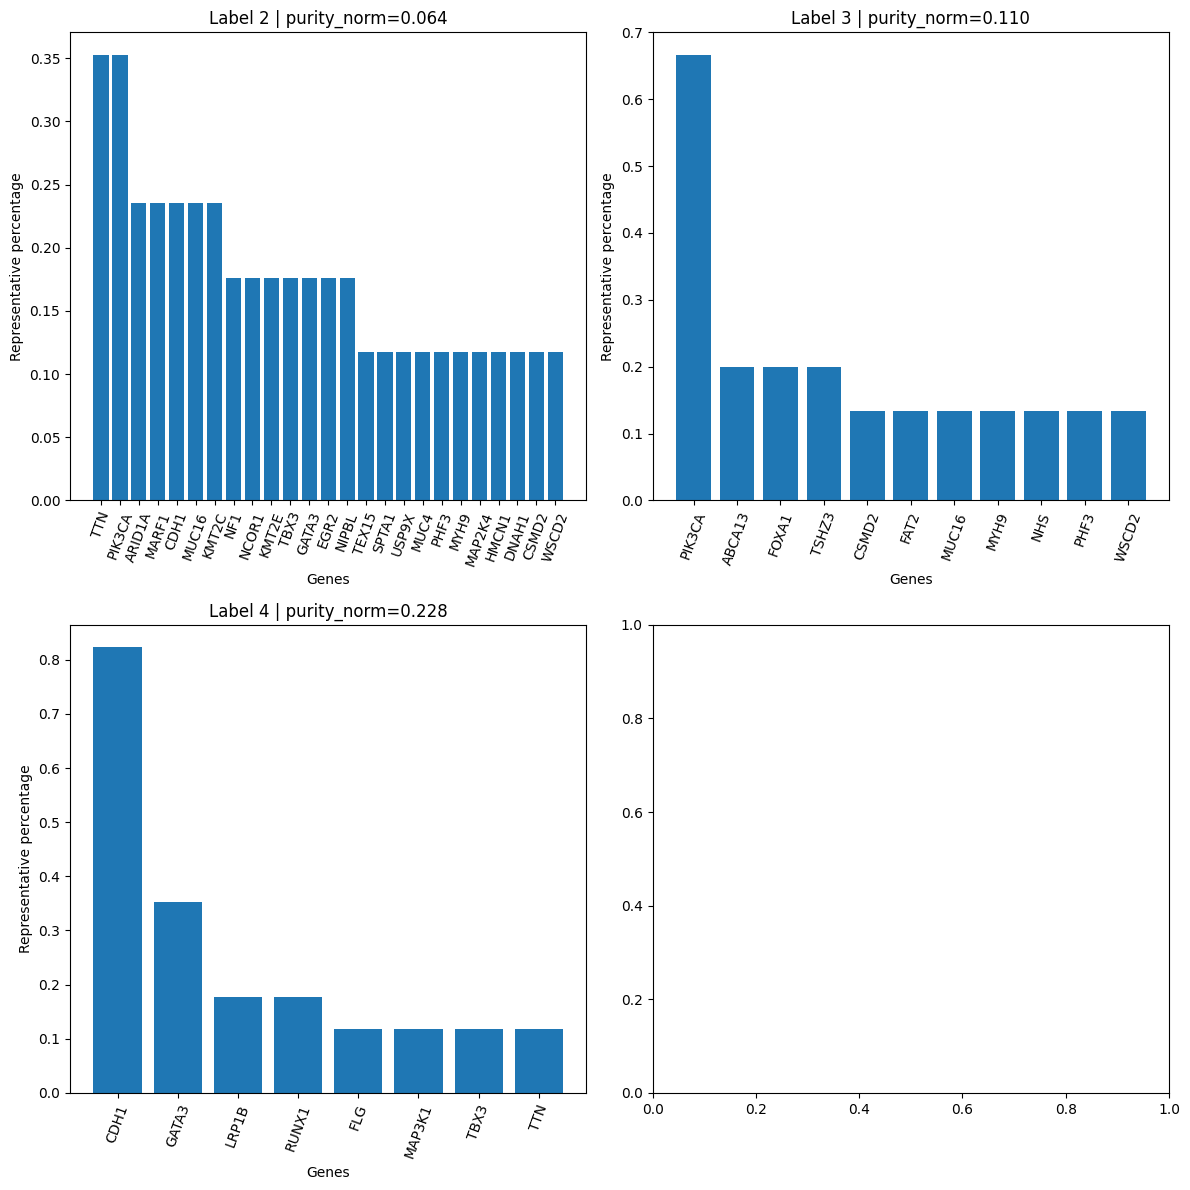

In [15]:
good_clusters = list(np.unique(df.label))

fig = gdc.plot_purity(dfpur, dfclu, good_clusters, min_perc=0.10)

In [ ]:
dfh

,k,cluster,n_genes,cluster_size,entropy,entropy_max,entropy_norm
29,10,9,5,9,2.311278,2.321928,0.995413
28,10,5,5,7,2.311278,2.321928,0.995413
25,9,8,5,7,2.311278,2.321928,0.995413
24,9,7,5,9,2.311278,2.321928,0.995413
20,8,4,5,7,2.311278,2.321928,0.995413
27,10,4,4,7,1.987773,2.000000,0.993887
19,8,3,5,8,2.307189,2.321928,0.993652
23,9,4,5,8,2.307189,2.321928,0.993652
21,8,5,5,10,2.307189,2.321928,0.993652
15,7,2,7,12,2.778689,2.807355,0.989789


In [ ]:
dfstat

In [ ]:
dfpiv.shape